In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

sns.set_theme(style="whitegrid")


file_path_r = Path.home() / "Downloads" / "region_country.xlsx"
region_country = pd.read_excel(file_path_r)

print("Data loaded successfully")
print("region_country shape:", region_country.shape)
print("columns:", list(region_country.columns))

Data loaded successfully
region_country shape: (100, 12)
columns: ['Region', 'country', 'number 2016', 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2019, 2020]


In [2]:
import re

# Reshape region_country data
rc = region_country.copy()
rc.columns = [str(c).strip() for c in rc.columns]

# Extract years from column names
year_map = {}
for col in rc.columns:
    m = re.search(r"(19\d{2}|20\d{2})", str(col))
    if m:
        year_map[col] = int(m.group(1))

if not year_map:
    raise ValueError("No year columns found in region_country")

rc = rc.rename(columns=year_map)
year_cols = sorted([c for c in rc.columns if isinstance(c, int)])

# Forward fill region name to country rows
rc["Region"] = rc["Region"].ffill()

# Separate region total rows from country rows
region_rows = rc[rc["country"].isna()].copy()
country_rows = rc[rc["country"].notna()].copy()

# Reshape to long format
country_long = country_rows.melt(
    id_vars=["Region", "country"], 
    value_vars=year_cols, 
    var_name="year", 
    value_name="fatalities"
)
country_long["fatalities"] = pd.to_numeric(country_long["fatalities"], errors="coerce").fillna(0)
country_long["year"] = country_long["year"].astype(int)

region_long = region_rows.melt(
    id_vars=["Region"], 
    value_vars=year_cols, 
    var_name="year", 
    value_name="fatalities"
)
region_long["fatalities"] = pd.to_numeric(region_long["fatalities"], errors="coerce").fillna(0)
region_long["year"] = region_long["year"].astype(int)

print("Data reshaped to long format")
display(country_long.head())

Data reshaped to long format


,Region,country,year,fatalities
0,North America,United States,2010,56.0
1,North America,Mexico,2010,1.0
2,North America,Canada,2010,4.0
3,North America,Bermuda,2010,0.0
4,North America,Greenland,2010,1.0


In [3]:
# ---------- GEOGRAPHIC MAPPING: DEATHS BY COUNTRY & YEAR ----------

# Aggregate country-level data for all years combined
country_totals = (
    country_long.groupby("country", as_index=False)["fatalities"]
    .sum()
    .sort_values("fatalities", ascending=False)
)

print("Country Deaths Summary (Top 20):")
display(country_totals.head(20))

# Create pivot table: countries as rows, years as columns
country_year_pivot = (
    country_long.pivot_table(
        index="country", 
        columns="year", 
        values="fatalities", 
        aggfunc="sum", 
        fill_value=0
    )
)

print("\n" + "="*60)
print("Country-Year Deaths Pivot Table")
print("="*60)
display(country_year_pivot.head())

Country Deaths Summary (Top 20):


,country,fatalities
78,United States,569.0
2,Australia,92.0
77,United Kingdom,69.0
11,Canada,59.0
44,Mexico,57.0
50,New Zealand,52.0
36,Italy,37.0
54,Philippines,31.0
52,Other,31.0
34,Indonesia,31.0



Country-Year Deaths Pivot Table


year,2010,2011,2012,2013,2014,2015,2016,2017,2019,2020
country,,,,,,,,,,
Antartica,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Antigua and Barbuda,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0
Australia,6.0,11.0,7.0,11.0,5.0,8.0,14.0,7.0,14.0,9.0
Austria,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Bahamas,1.0,0.0,0.0,1.0,2.0,1.0,4.0,2.0,2.0,0.0


In [4]:
# Calculate statistics for each country: total, mean, std, variance
country_stats = pd.DataFrame({
    "Total_Deaths": country_year_pivot.sum(axis=1),
    "Mean_Per_Year": country_year_pivot.mean(axis=1),
    "StdDev": country_year_pivot.std(axis=1),
    "Variance": country_year_pivot.var(axis=1),
    "Max_Year": country_year_pivot.max(axis=1),
    "Min_Year": country_year_pivot.min(axis=1),
    "CV": (country_year_pivot.std(axis=1) / country_year_pivot.mean(axis=1)).replace([np.inf, -np.inf], 0).fillna(0)
}).sort_values("Total_Deaths", ascending=False)

print("Country Statistics (High Variability / High Density):")
display(country_stats.head(15))

# Identify high-density countries (most total deaths)
high_density_countries = country_stats.nlargest(10, "Total_Deaths").index.tolist()
print(f"\nHigh-Density Countries (Top 10): {high_density_countries}")

# Identify high-variation countries (high std dev)
high_variation_countries = country_stats.nlargest(10, "StdDev").index.tolist()
print(f"\nHigh-Variation Countries (Top 10 by Std Dev): {high_variation_countries}")

# Identify high-variation relative to mean (high coefficient of variation)
high_cv_countries = country_stats[country_stats["Total_Deaths"] >= 5].nlargest(10, "CV").index.tolist()
print(f"\nHigh Relative Variation (Top 10 by CV, min 5 deaths): {high_cv_countries}")

Country Statistics (High Variability / High Density):


,Total_Deaths,Mean_Per_Year,StdDev,Variance,Max_Year,Min_Year,CV
country,,,,,,,
United States,569.0,56.9,11.100050,123.211111,74.0,39.0,0.195080
Australia,92.0,9.2,3.190263,10.177778,14.0,5.0,0.346768
United Kingdom,69.0,6.9,2.685351,7.211111,12.0,2.0,0.389181
Canada,59.0,5.9,1.969207,3.877778,10.0,4.0,0.333764
Mexico,57.0,5.7,2.907844,8.455556,9.0,1.0,0.510148
New Zealand,52.0,5.2,2.658320,7.066667,8.0,0.0,0.511215
Italy,37.0,3.7,1.766981,3.122222,7.0,1.0,0.477562
Philippines,31.0,3.1,2.330951,5.433333,6.0,0.0,0.751920
Other,31.0,3.1,4.998889,24.988889,15.0,0.0,1.612545



High-Density Countries (Top 10): ['United States', 'Australia', 'United Kingdom', 'Canada', 'Mexico', 'New Zealand', 'Italy', 'Philippines', 'Other', 'Indonesia']

High-Variation Countries (Top 10 by Std Dev): ['United States', 'Other', 'South Africa', 'Australia', 'France', 'Mexico', 'United Kingdom', 'New Zealand', 'Indonesia', 'Philippines']

High Relative Variation (Top 10 by CV, min 5 deaths): ['South Korea', 'Antigua and Barbuda', 'Great Britain', 'French Polynesia', 'Vietnam', 'Turks and Caicos', 'Other', 'Greece', 'Brazil', 'Virgin Islands']


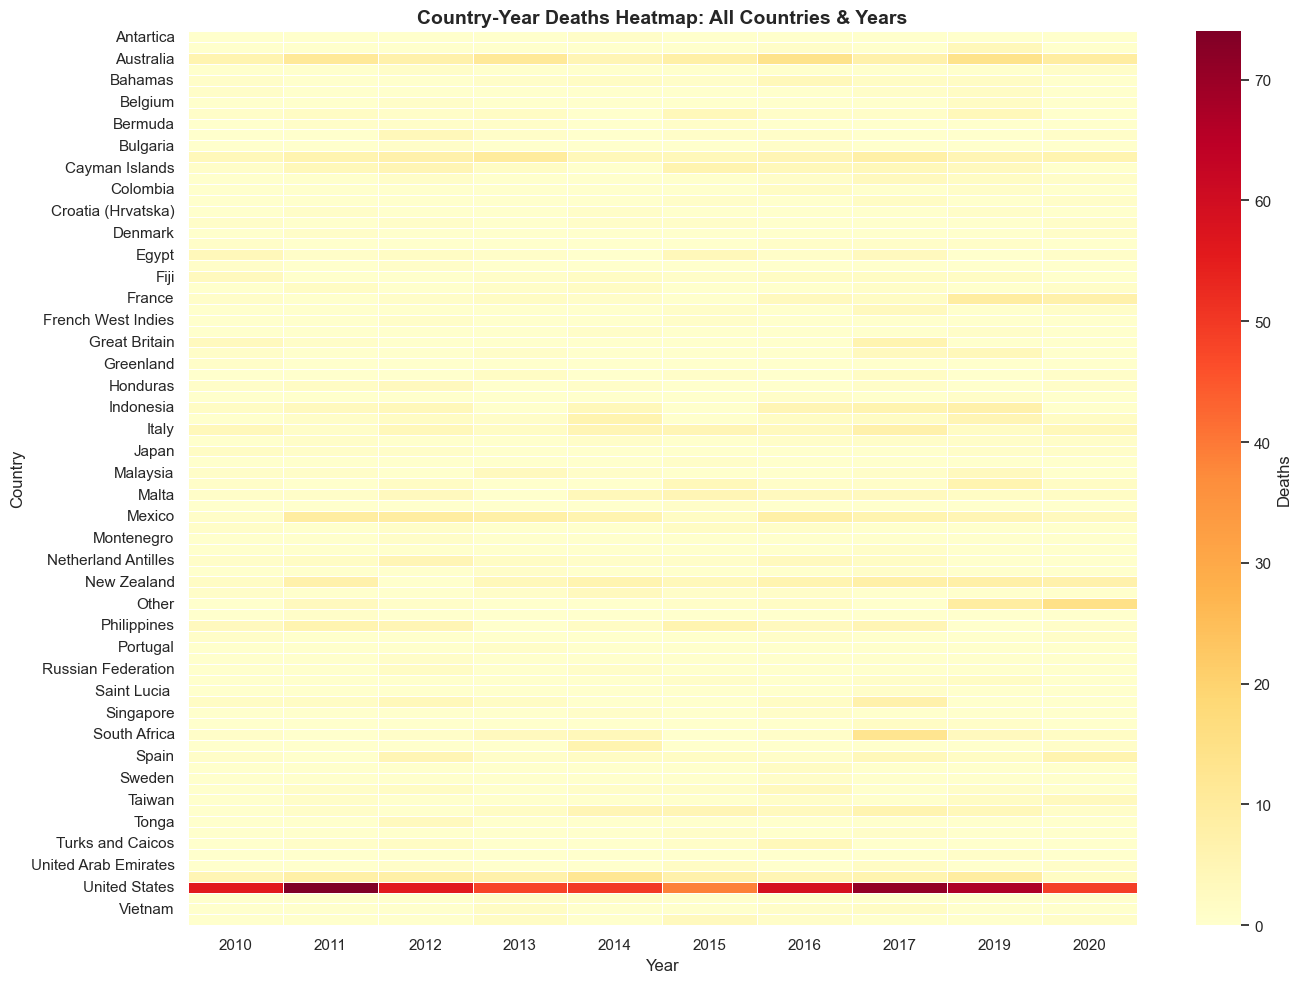

In [5]:
# ---------- VISUALIZATION 1: COUNTRY-YEAR HEATMAP (Total Deaths) ----------

# Plot heatmap: countries vs years (all countries)
plt.figure(figsize=(14, 10))
sns.heatmap(
    country_year_pivot, 
    cmap="YlOrRd", 
    annot=False, 
    cbar_kws={"label": "Deaths"}, 
    linewidths=0.5
)
plt.title("Country-Year Deaths Heatmap: All Countries & Years", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

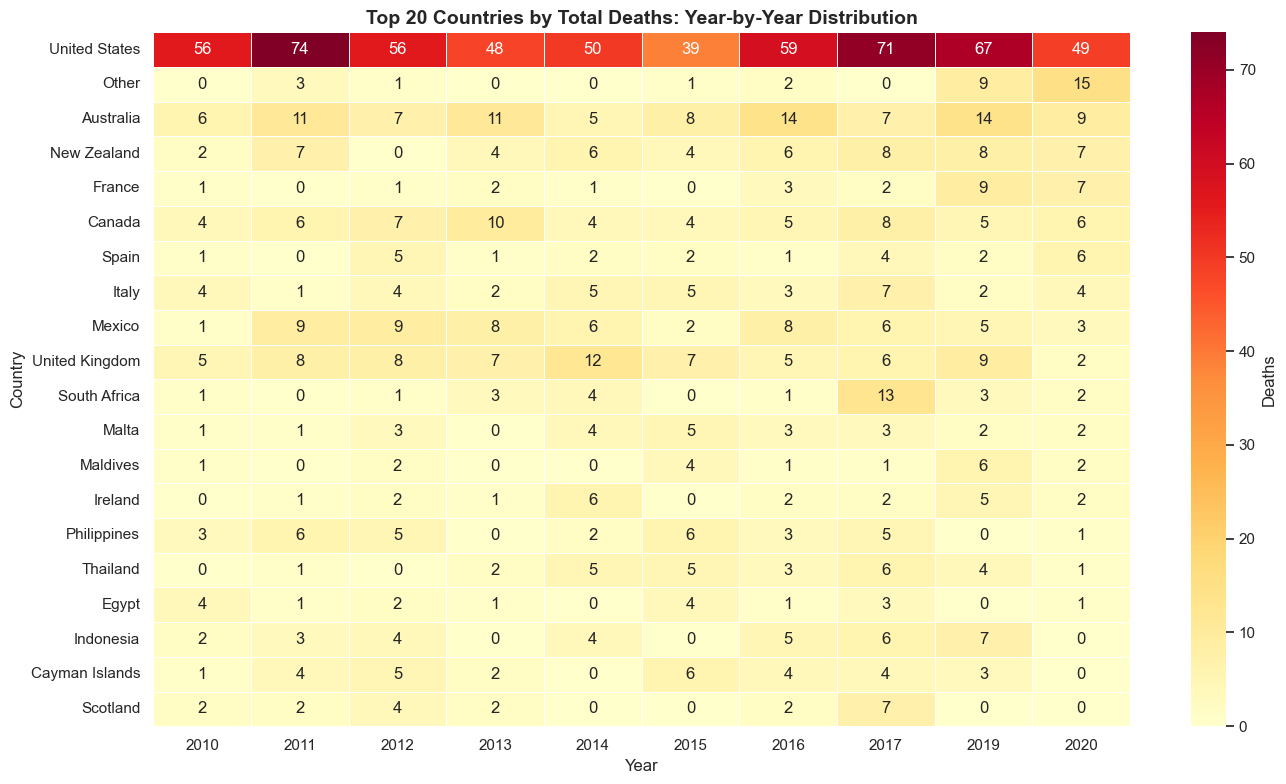

In [6]:
# Plot heatmap: top 20 countries only (more readable)
top20_countries = country_stats.nlargest(20, "Total_Deaths").index
country_heatmap_top20 = country_year_pivot.loc[top20_countries].sort_values(
    by=country_year_pivot.columns[-1], 
    ascending=False
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    country_heatmap_top20, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="g", 
    cbar_kws={"label": "Deaths"}, 
    linewidths=0.5
)
plt.title("Top 20 Countries by Total Deaths: Year-by-Year Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

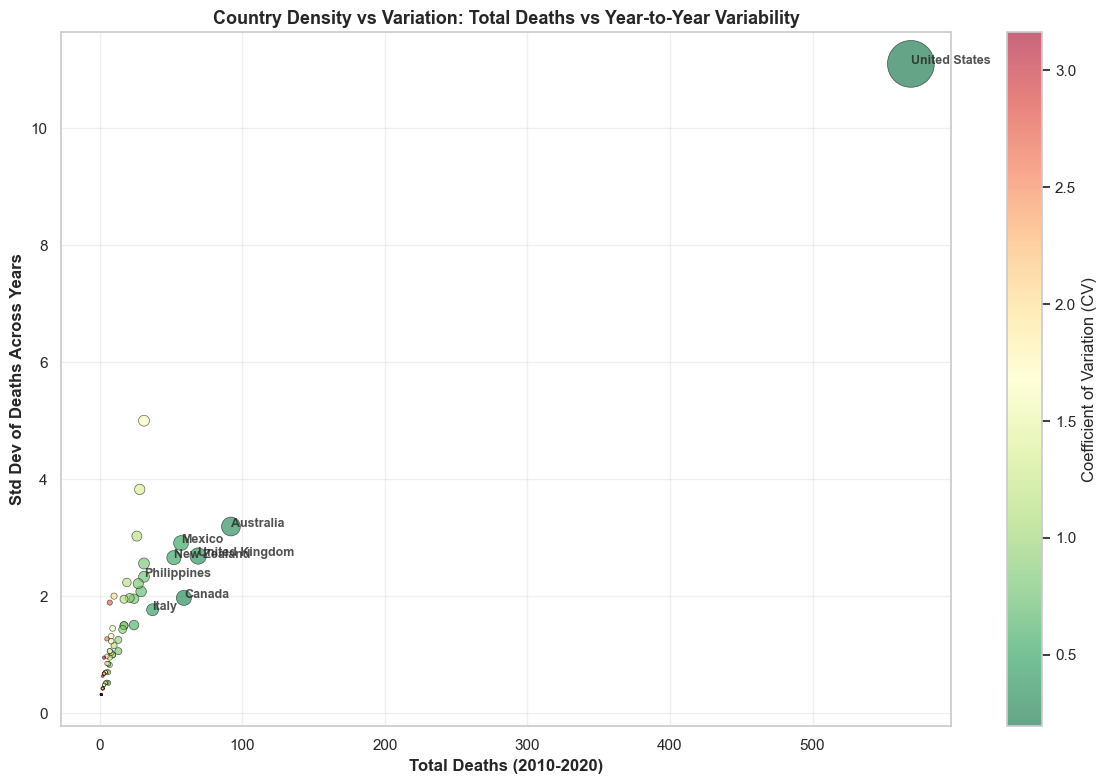

In [8]:
# ---------- VISUALIZATION 2: DENSITY vs VARIATION SCATTER PLOT ----------

scatter_data = country_stats.reset_index().rename(columns={"index": "country"})
scatter_data = scatter_data[scatter_data["Total_Deaths"] > 0]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    scatter_data["Total_Deaths"], 
    scatter_data["StdDev"], 
    s=scatter_data["Mean_Per_Year"]*20,
    alpha=0.6, 
    c=scatter_data["CV"],
    cmap="RdYlGn_r",
    edgecolors="black",
    linewidth=0.5
)
plt.colorbar(scatter, label="Coefficient of Variation (CV)")
plt.xlabel("Total Deaths (2010-2020)", fontsize=12, fontweight="bold")
plt.ylabel("Std Dev of Deaths Across Years", fontsize=12, fontweight="bold")
plt.title("Country Density vs Variation: Total Deaths vs Year-to-Year Variability", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)

# Annotate top countries
for idx, row in scatter_data.nlargest(8, "Total_Deaths").iterrows():
    plt.annotate(row["country"], (row["Total_Deaths"], row["StdDev"]), 
                fontsize=9, alpha=0.8, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Table of high-density and high-variation
print("\n" + "="*80)
print("HIGH-DENSITY COUNTRIES (Most Total Deaths)")
print("="*80)
high_density = country_stats.nlargest(15, "Total_Deaths")[["Total_Deaths", "Mean_Per_Year", "StdDev", "CV"]]
display(high_density)

print("\n" + "="*80)
print("HIGH-VARIATION COUNTRIES (Most Unstable Year-to-Year Patterns)")
print("="*80)
high_var = country_stats[country_stats["Total_Deaths"] >= 10].nlargest(15, "StdDev")[["Total_Deaths", "Mean_Per_Year", "StdDev", "CV"]]
display(high_var)

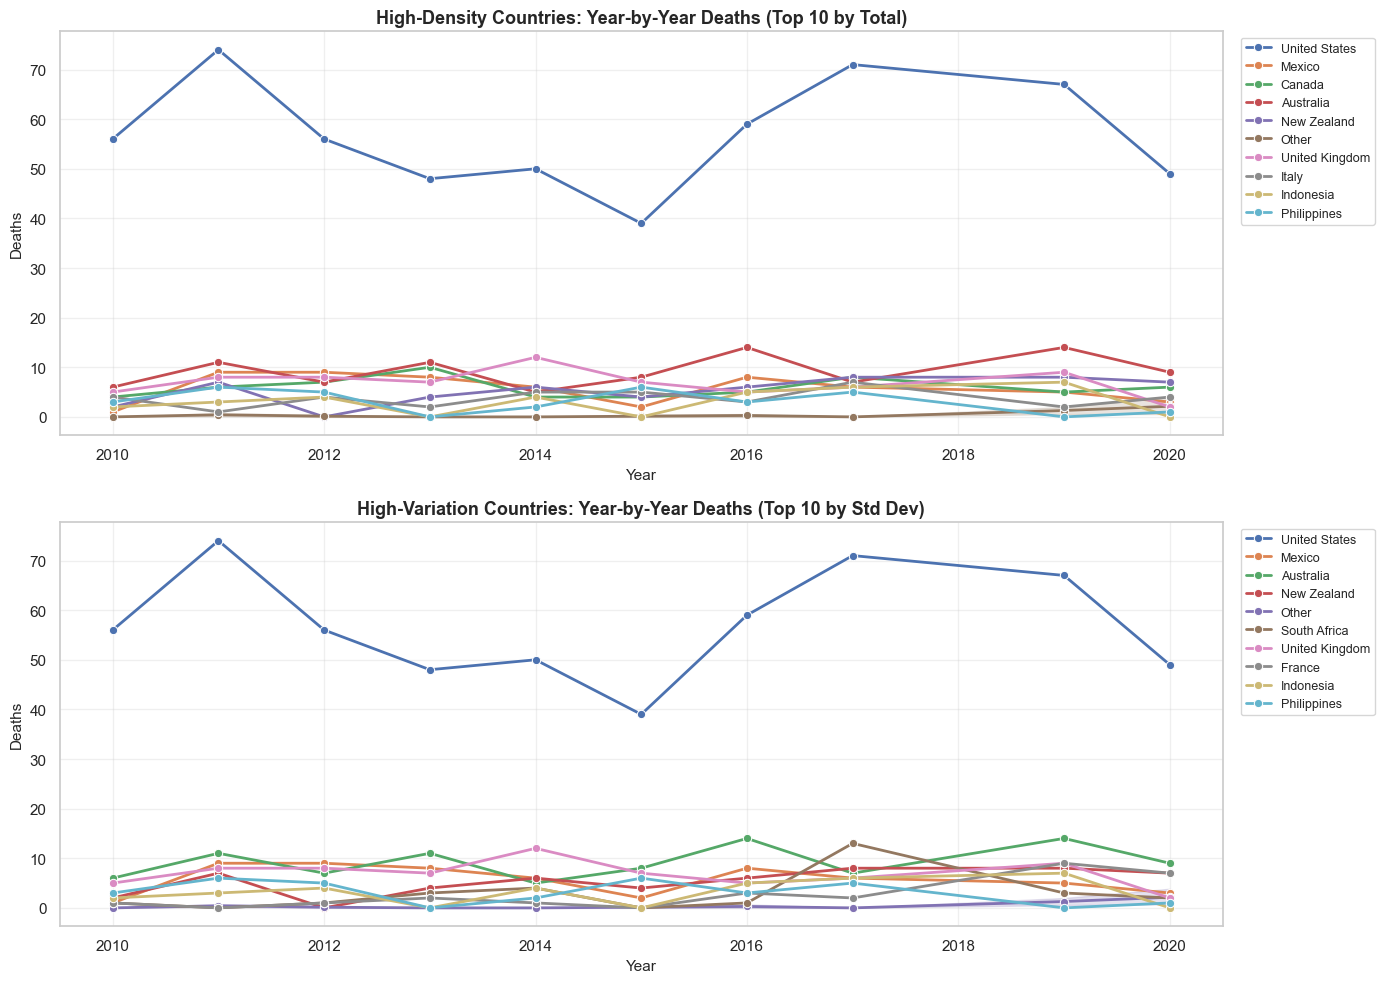

In [9]:
# ---------- VISUALIZATION 3: TRENDS OVER TIME ----------

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# TOP: High-Density Countries (most consistent contributors)
high_density_data = country_long[country_long["country"].isin(high_density_countries)].copy()
sns.lineplot(data=high_density_data, x="year", y="fatalities", hue="country", marker="o", ax=axes[0], linewidth=2)
axes[0].set_title("High-Density Countries: Year-by-Year Deaths (Top 10 by Total)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year", fontsize=11)
axes[0].set_ylabel("Deaths", fontsize=11)
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
axes[0].grid(True, alpha=0.3)

# BOTTOM: High-Variation Countries (unpredictable patterns)
high_var_data = country_long[country_long["country"].isin(high_variation_countries)].copy()
sns.lineplot(data=high_var_data, x="year", y="fatalities", hue="country", marker="o", ax=axes[1], linewidth=2)
axes[1].set_title("High-Variation Countries: Year-by-Year Deaths (Top 10 by Std Dev)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year", fontsize=11)
axes[1].set_ylabel("Deaths", fontsize=11)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ---------- VISUALIZATION 4: PLOTLY CHOROPLETH MAPS ----------

# Country code mapping
country_code_map = {
    "USA": "USA",
    "United States": "USA",
    "Australia": "AUS",
    "Philippines": "PHL",
    "Mexico": "MEX",
    "Thailand": "THA",
    "Indonesia": "IDN",
    "Egypt": "EGY",
    "Canada": "CAN",
    "Brazil": "BRA",
    "Germany": "DEU",
    "France": "FRA",
    "United Kingdom": "GBR",
    "Italy": "ITA",
    "Spain": "ESP",
    "Netherlands": "NLD",
    "Switzerland": "CHE",
    "Norway": "NOR",
    "South Africa": "ZAF",
    "Kenya": "KEN",
    "New Zealand": "NZL",
    "Japan": "JPN",
    "China": "CHN",
    "India": "IND",
    "Israel": "ISR",
    "Greece": "GRC",
    "Croatia": "HRV",
    "Belize": "BLZ",
    "Cayman Islands": "CYM",
    "Puerto Rico": "PRI",
    "Virgin Islands": "VIR",
    "Curacao": "CUW",
    "Barbados": "BRB",
    "Turks and Caicos": "TCA",
    "Bonaire": "BES",
    "Guam": "GUM",
    "Palau": "PLW",
    "Papua New Guinea": "PNG",
    "Micronesia": "FSM",
    "Malta": "MLT",
    "Cyprus": "CYP",
}

# Add ISO codes to country data
country_long_iso = country_long.copy()
country_long_iso["ISO"] = country_long_iso["country"].map(country_code_map)

# Get unmapped countries
unmapped = country_long_iso[country_long_iso["ISO"].isna()]["country"].unique()
if len(unmapped) > 0:
    print(f"Unmapped countries (will not appear on map): {list(unmapped)[:10]}")

# Remove unmapped for cleaner visualization
country_long_iso = country_long_iso.dropna(subset=["ISO"])

# Create choropleth for total deaths (all years combined)
country_totals_iso = country_long_iso.groupby(["country", "ISO"], as_index=False)["fatalities"].sum()

fig_total = go.Figure(data=go.Choropleth(
    locations=country_totals_iso["ISO"],
    z=country_totals_iso["fatalities"],
    text=country_totals_iso["country"],
    colorscale=[
        [0.0, "#f3fbff"],
        [0.2, "#d7f0f2"],
        [0.45, "#9fd8d3"],
        [0.7, "#5fb7b2"],
        [1.0, "#2f7f8f"]
    ],
    autocolorscale=False,
    reversescale=False,
    marker_line_color="darkgray",
    colorbar_title="Total Deaths<br>(2010-2020)",
    hovertemplate="<b>%{text}</b><br>Deaths: %{z}<extra></extra>"
))

fig_total.update_layout(
    title_text="Global Scuba Diving Fatalities: Geographic Density (Total 2010-2020)",
    title_font_size=14,
    geo=dict(
        scope="world",
        projection_type="natural earth",
        showland=True,
        landcolor="rgb(243, 243, 243)"
    ),
    height=600,
    width=1200
)
fig_total.show()

print("\nChoropleth map shows total fatalities by country across the entire period.")

Unmapped countries (will not appear on map): ['Bermuda', 'Greenland', 'French Polynesia', 'Marshall Island', 'Tonga', 'Solomon Island', 'Vanuatu', 'Fiji', 'Bahamas', 'Netherland Antilles']



Choropleth map shows total fatalities by country across the entire period.


In [13]:
# ---------- VISUALIZATION 5: ANIMATED CHOROPLETH (Year-by-Year) ----------

country_year_iso = country_long_iso.groupby(["year", "country", "ISO"], as_index=False)["fatalities"].sum()

fig_animated = px.choropleth(
    country_year_iso,
    locations="ISO",
    color="fatalities",
    hover_name="country",
    color_continuous_scale=[
        [0.0, "#f3fbff"],
        [0.2, "#d7f0f2"],
        [0.45, "#9fd8d3"],
        [0.7, "#5fb7b2"],
        [1.0, "#2f7f8f"]
    ],
    animation_frame="year",
    animation_group="country",
    range_color=[0, country_year_iso["fatalities"].quantile(0.95)],
    title="Scuba Diving Fatalities by Country: Year-by-Year Evolution (2010-2020)",
    labels={"fatalities": "Deaths"}
)

fig_animated.update_geos(
    scope="world",
    projection_type="natural earth",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    coastlinecolor="rgb(204, 204, 204)"
)

fig_animated.update_layout(
    height=600,
    width=1200,
    font_size=11,
    title_font_size=14
)

fig_animated.update_layout(
    sliders=[{
        "active": 0,
        "yanchor": "top",
        "y": 0,
        "xanchor": "left",
        "currentvalue": {"prefix": "Year: ", "visible": True, "xanchor": "right"},
        "pad": {"b": 10, "t": 50},
        "len": 0.9,
    }]
)

fig_animated.show()

print("Animated map shows how geographic patterns of fatalities shifted year-by-year.")

Animated map shows how geographic patterns of fatalities shifted year-by-year.


In [7]:
# ---------- SUMMARY: GEOGRAPHIC PATTERNS & KEY FINDINGS ----------

print("\n" + "="*80)
print("GEOGRAPHIC ANALYSIS: KEY FINDINGS")
print("="*80)

# 1. Overall statistics
total_deaths_worldwide = country_long["fatalities"].sum()
total_countries = country_long["country"].nunique()
print(f"\nGlobal: {int(total_deaths_worldwide)} deaths across {total_countries} countries (2010-2020)")

# 2. Concentration analysis
cumulative_stats = country_stats["Total_Deaths"].cumsum() / country_stats["Total_Deaths"].sum() * 100
print(f"\nConcentration:")
print(f"  - Top 5 countries account for {cumulative_stats.iloc[4]:.1f}% of deaths")
print(f"  - Top 10 countries account for {cumulative_stats.iloc[9]:.1f}% of deaths")
print(f"  - Top 20 countries account for {cumulative_stats.iloc[19]:.1f}% of deaths")

# 3. High-density clusters
print(f"\n\nHIGH-DENSITY CLUSTERS (Most Deaths, 2010-2020):")
high_dens = country_stats.nlargest(8, "Total_Deaths")[["Total_Deaths", "Mean_Per_Year", "Max_Year"]]
for idx, (country, row) in enumerate(high_dens.iterrows(), 1):
    print(f"  {idx}. {country}: {int(row['Total_Deaths'])} deaths (avg {row['Mean_Per_Year']:.1f}/year, peak {int(row['Max_Year'])})")

# 4. High-variation countries
print(f"\n\nHIGH-VARIATION REGIONS (Unpredictable Patterns - Top 5 by Std Dev):")
high_var_sample = country_stats[country_stats["Total_Deaths"] >= 10].nlargest(5, "StdDev")
for idx, (country, row) in enumerate(high_var_sample.iterrows(), 1):
    print(f"  {idx}. {country}:")
    print(f"     Total: {int(row['Total_Deaths'])}, Mean: {row['Mean_Per_Year']:.1f}/year")
    print(f"     Std Dev: {row['StdDev']:.2f}, Range: {int(row['Min_Year'])} to {int(row['Max_Year'])} deaths/year")

# 5. Stability analysis
print(f"\n\nMOST STABLE CONTRIBUTORS (Consistent Deaths Year-to-Year - Min CV, >5 deaths):")
stable = country_stats[(country_stats["Total_Deaths"] >= 5) & (country_stats["CV"] > 0)].nsmallest(5, "CV")
for idx, (country, row) in enumerate(stable.iterrows(), 1):
    if row["CV"] > 0:
        print(f"  {idx}. {country}: {int(row['Total_Deaths'])} deaths, CV={row['CV']:.2f} (very stable)")

# 6. Emerging/declining trends
print(f"\n\nTRENDS (Countries with Largest Increase or Decrease):")
country_recent_years = country_long[country_long["year"].isin([2018, 2019, 2020])].groupby("country")["fatalities"].sum()
country_early_years = country_long[country_long["year"].isin([2010, 2011, 2012])].groupby("country")["fatalities"].sum()

trend_comparison = pd.DataFrame({
    "Early_Avg": country_early_years / 3,
    "Recent_Avg": country_recent_years / 3
})
trend_comparison["Change"] = trend_comparison["Recent_Avg"] - trend_comparison["Early_Avg"]
trend_comparison = trend_comparison[trend_comparison["Early_Avg"] + trend_comparison["Recent_Avg"] > 0].sort_values("Change", key=abs, ascending=False)

print("  Increasing trend:")
increasing = trend_comparison[trend_comparison["Change"] > 0].head(3)
for country, row in increasing.iterrows():
    print(f"    {country}: {row['Early_Avg']:.1f} → {row['Recent_Avg']:.1f} deaths/year (+{row['Change']:.1f})")

print("  Decreasing trend:")
decreasing = trend_comparison[trend_comparison["Change"] < 0].head(3)
for country, row in decreasing.iterrows():
    print(f"    {country}: {row['Early_Avg']:.1f} → {row['Recent_Avg']:.1f} deaths/year ({row['Change']:.1f})")

print("\n" + "="*80)


GEOGRAPHIC ANALYSIS: KEY FINDINGS

Global: 1551 deaths across 82 countries (2010-2020)

Concentration:
  - Top 5 countries account for 54.5% of deaths
  - Top 10 countries account for 66.3% of deaths
  - Top 20 countries account for 81.2% of deaths


HIGH-DENSITY CLUSTERS (Most Deaths, 2010-2020):
  1. United States: 569 deaths (avg 56.9/year, peak 74)
  2. Australia: 92 deaths (avg 9.2/year, peak 14)
  3. United Kingdom: 69 deaths (avg 6.9/year, peak 12)
  4. Canada: 59 deaths (avg 5.9/year, peak 10)
  5. Mexico: 57 deaths (avg 5.7/year, peak 9)
  6. New Zealand: 52 deaths (avg 5.2/year, peak 8)
  7. Italy: 37 deaths (avg 3.7/year, peak 7)
  8. Philippines: 31 deaths (avg 3.1/year, peak 6)


HIGH-VARIATION REGIONS (Unpredictable Patterns - Top 5 by Std Dev):
  1. United States:
     Total: 569, Mean: 56.9/year
     Std Dev: 11.10, Range: 39 to 74 deaths/year
  2. Other:
     Total: 31, Mean: 3.1/year
     Std Dev: 5.00, Range: 0 to 15 deaths/year
  3. South Africa:
     Total: 28, Me

In [15]:
# ---------- STATISTICAL TREND TESTS: GLOBAL + PER-COUNTRY ----------
import sys, subprocess
from scipy.stats import kendalltau, theilslopes
try:
    import statsmodels.api as sm
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels'])
    import statsmodels.api as sm

# Aggregate global totals per year
global_year = country_long.groupby('year', as_index=False)['fatalities'].sum().sort_values('year')
display(global_year)

# OLS regression: fatalities ~ year
X = sm.add_constant(global_year['year'])
y = global_year['fatalities']
model = sm.OLS(y, X).fit()
print('OLS slope (deaths per year):', model.params['year'])
print('OLS p-value:', model.pvalues['year'])
print(model.summary())

# Mann–Kendall (approx) via Kendall's tau
tau, p_kendall = kendalltau(global_year['year'], global_year['fatalities'])
print(f"Kendall tau: {tau:.4f}, p-value: {p_kendall:.4f}")

# Theil–Sen slope (robust)
ts_slope, ts_intercept, ts_lo, ts_up = theilslopes(global_year['fatalities'].values, global_year['year'].values, 0.95)
print(f'Theil–Sen slope: {ts_slope:.4f} deaths/year (95% CI {ts_lo:.4f}, {ts_up:.4f})')

if model.pvalues['year'] < 0.05:
    direction = 'increasing' if model.params['year'] > 0 else 'decreasing'
    print(f'Global trend: statistically significant {direction} (OLS p<0.05).')
else:
    print('Global trend: no statistically significant linear trend detected (OLS p>=0.05).')

# ---------- PER-COUNTRY TESTS (Kendall + Theil–Sen) ----------
from statsmodels.stats.multitest import multipletests
countries = []
years = sorted(country_long['year'].unique())
for country, grp in country_long.groupby('country'):
    ser = grp.groupby('year')['fatalities'].sum().reindex(years, fill_value=0)
    # require at least 5 years with any data to test
    if (ser>0).sum() < 5:
        continue
    tau_c, p_c = kendalltau(list(ser.index), ser.values)
    try:
        ts_slope_c, ts_intercept_c, ts_lo_c, ts_up_c = theilslopes(ser.values, ser.index, 0.95)
    except Exception:
        ts_slope_c, ts_intercept_c, ts_lo_c, ts_up_c = (np.nan, np.nan, np.nan, np.nan)
    countries.append({'country': country, 'tau': tau_c, 'p': p_c, 'theil_sen_slope': ts_slope_c, 'total': ser.sum()})

results_df = pd.DataFrame(countries).set_index('country')
if results_df.empty:
    print('No countries met the minimum data requirement for per-country tests.')
else:
    # multiple testing correction (FDR)
    reject, pvals_corrected, _, _ = multipletests(results_df['p'].values, alpha=0.05, method='fdr_bh')
    results_df['p_adj'] = pvals_corrected
    results_df['significant'] = reject
    # report significant increases/decreases
    sig = results_df[results_df['significant']].copy()
    sig['direction'] = sig['theil_sen_slope'].apply(lambda s: 'increasing' if s>0 else ('decreasing' if s<0 else 'flat'))
    print('\nSignificant countries after FDR correction (alpha=0.05):')
    display(sig.sort_values('p_adj').head(20))
    print('\nTop 10 increasing (by Theil–Sen slope):')
    display(sig[sig['theil_sen_slope']>0].sort_values('theil_sen_slope', ascending=False).head(10))
    print('\nTop 10 decreasing (by Theil–Sen slope):')
    display(sig[sig['theil_sen_slope']<0].sort_values('theil_sen_slope').head(10))


,year,fatalities
0,2010,117.0
1,2011,157.0
2,2012,161.0
3,2013,127.0
4,2014,143.0
5,2015,130.0
6,2016,167.0
7,2017,212.0
8,2019,199.0
9,2020,138.0


OLS slope (deaths per year): 4.488511488511428
OLS p-value: 0.15762083894156698
                            OLS Regression Results                            
Dep. Variable:             fatalities   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     2.430
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.158
Time:                        19:46:00   Log-Likelihood:                -46.679
No. Observations:                  10   AIC:                             97.36
Df Residuals:                       8   BIC:                             97.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

/Users/mirandagrein/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


,tau,p,theil_sen_slope,total,p_adj,significant,direction
country,,,,,,,



Top 10 increasing (by Theil–Sen slope):


,tau,p,theil_sen_slope,total,p_adj,significant,direction
country,,,,,,,



Top 10 decreasing (by Theil–Sen slope):


,tau,p,theil_sen_slope,total,p_adj,significant,direction
country,,,,,,,


In [14]:
# ---------- EXPORT INTERACTIVE MAP FOR HTML ----------
from pathlib import Path

map_output = Path("/Users/mirandagrein/Documents/final project/map_total.html")
fig_animated.write_html(map_output, include_plotlyjs="cdn", full_html=True, config={"scrollZoom": True, "displayModeBar": True})
print(f"Saved interactive map to: {map_output}")

Saved interactive map to: /Users/mirandagrein/Documents/final project/map_total.html
